In [1]:
conda install pandas matplotlib notebook ipykernel

/opt/conda/lib/python3.9/site-packages/conda/base/context.py:211: FutureWarning: Adding 'defaults' to channel list implicitly is deprecated and will be removed in 25.9. 

To remove this warning, please choose a default channel explicitly with conda's regular configuration system, e.g. by adding 'defaults' to the list of channels:

  conda config --add channels defaults

For more information see https://docs.conda.io/projects/conda/en/stable/user-guide/configuration/use-condarc.html

  deprecated.topic(
Retrieving notices: done

EnvironmentNotWritableError: The current user does not have write permissions to the target environment.
  environment location: /opt/conda/envs/anaconda-2025.12-py312
  uid: 2774982
  gid: 60000



Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install pandas matplotlib notebook ipykernel

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Note: you may need to restart the kernel to use updated packages.


# Who's Fault Is It Really?: Mapping Extralegal Killing in Antebellum America, 1849–1865
**Author:** Valerie Xu

---

**Historical Question:**
Did different regions of the United States exhibit distinct patterns of extralegal violence between 1849 and 1865 — and does the data challenge the narrative that positioned the North as a haven of racial tolerance relative to the South?

**Argument:**
Racialized extralegal violence was not a Southern aberration but a national practice. The South had a higher probability of racial violence per incident 78%, but the West and North produced rates 53% that fundamentally challenge the North/South moral binary taught in American history classrooms.

This is really interesting, because when students learn about US history, they are generally told that the North was this “haven” or even “utopia” of freedom and had no hatred towards people of color. 25% is a significant difference, but it’s a small difference compared to how polar we think the North/West and South treated POC.


---
## How to Use This Notebook
Run all cells top to bottom in order. Each section builds on the variables created in the previous one. The notebook is divided into two sections:
- **Section 1** (Cells 3–27): Core dataset analysis, 1849–1865
- **Section 2** (Cell 28+): Continuity analysis — lynching and anti-Chinese violence datasets

---
## Section 1: Core Dataset — Extralegal Violence, 1849–1865

### Setup & Imports
Standard libraries used throughout: `pandas` for data manipulation, `matplotlib` for visualization, `json` for loading the GeoJSON source file, and `re` for text processing in the NLP section.

In [3]:
import json
import re
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

### Loading the Dataset
The source file `Year_1849_1865.geojson` contains 320 documented extralegal incidents drawn from historical records across the United States. Each record captures state, year, incident type, victim classification, and a free-text description of the event.

> **Bias warning:** This dataset reflects what was *recorded*, not what *occurred*. Regions with weaker newspaper infrastructure are systematically undercounted. Violence against Indigenous peoples in the West and rural communities far from county seats can be underrepresented. All findings should be treated as floors, not ceilings.

In [4]:
file_path = "Year_1849_1865.geojson"

with open(file_path, "r", encoding="utf-8") as f:
    geojson_data = json.load(f)

records = [feature["properties"] for feature in geojson_data["features"]]
df = pd.DataFrame(records)

print("Dataset loaded.")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print("\nColumns:")
print(df.columns.tolist())

df.head()

Dataset loaded.
Rows: 320, Columns: 18

Columns:
['Year', 'Date', 'State', 'Sublocation', 'Location', 'Lat', 'Long', 'Description', 'Source', 'Type', 'Rioter Classification', 'Target Classification', 'Actions', 'Recorded # Killed', 'Recorded # Injured', 'Persons Named as Rioters', 'Persons Named as Targets', 'Note']


,Year,Date,State,Sublocation,Location,Lat,Long,Description,Source,Type,Rioter Classification,Target Classification,Actions,Recorded # Killed,Recorded # Injured,Persons Named as Rioters,Persons Named as Targets,Note
0,1849,1849/01,California,Dry Diggings,Dry Diggings,38.727510,-120.799800,Janurary: Three men hanged. One for alleged ho...,None,None,None,None,None,NaN,NaN,None,None,None
1,1849,None,Arkansas,Phillips Co.,Phillips Co. AR,34.379810,-90.819060,Burning of enslaved man for allegedly murderin...,"Orville W. Taylor, Negro Slavery on Arkansas (...",Racial; Slavery; Vigilante; Law,White; Vigilante,Black; Slave; Alleged Criminal; Alleged Murderer,Lethal Violence; Mutilation,1.0,NaN,None,None,PTH
2,1849,1849/05,New York,New York City,NYC,40.720368,-74.001098,May: Astor Place Riot. Long-time feud between ...,"Cook.Armies, p.24-27",Theater,Unknown,Theater; Actor; Legal; Law Officer; Military; ...,Lethal Violence,22.0,NaN,Edwin Forrest,William C. MacReady,None
3,1849,1849/07,Pennsylvania,Philadelphia,Philadelphia,39.901530,-75.176711,June: Fire purposefully set so a gang could at...,"Scharf and Wescott, p.691-692",Firefighter,Firefighter; Franklin Hose; Gang,Firefighter; Franklin Hose; Gang,Lethal Violence,1.0,NaN,None,None,None
4,1849,1849/07,Illinois,Massac Co.,"Massac Co., Illinois",37.240106,-88.724884,July: Flatheads and Regulators fight at Linn F...,"Eteheson. ""Good Men,"" p.17;Lethal Imagination,...",Vigilante; Law; Gang,Vigilante; Regulator (Vigilante); Gang; Flathead,Vigilante; Regulator (Vigilante); Gang; Flathead,Lethal Violence; Non-Lethal Violence,3.0,6.0,None,None,None


### Data Cleaning
Standardizing column names and stripping whitespace from text fields. This step ensures consistent string matching in the classification and NLP steps below.

In [5]:
df = df.copy()
df.columns = [col.strip() for col in df.columns]

text_cols = [
    "State", "Sublocation", "Location", "Description", "Source", "Type",
    "Rioter Classification", "Target Classification", "Actions", "Note"
]

for col in text_cols:
    if col in df.columns:
        df[col] = df[col].fillna("").astype(str).str.strip()

if "Year" in df.columns:
    df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
    df = df.dropna(subset=["Year"])
    df["Year"] = df["Year"].astype(int)

for col in ["Lat", "Long", "Recorded # Killed", "Recorded # Injured"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

print("Shape after cleaning:", df.shape)
df.head()

Shape after cleaning: (320, 18)


,Year,Date,State,Sublocation,Location,Lat,Long,Description,Source,Type,Rioter Classification,Target Classification,Actions,Recorded # Killed,Recorded # Injured,Persons Named as Rioters,Persons Named as Targets,Note
0,1849,1849/01,California,Dry Diggings,Dry Diggings,38.727510,-120.799800,Janurary: Three men hanged. One for alleged ho...,,,,,,NaN,NaN,None,None,
1,1849,None,Arkansas,Phillips Co.,Phillips Co. AR,34.379810,-90.819060,Burning of enslaved man for allegedly murderin...,"Orville W. Taylor, Negro Slavery on Arkansas (...",Racial; Slavery; Vigilante; Law,White; Vigilante,Black; Slave; Alleged Criminal; Alleged Murderer,Lethal Violence; Mutilation,1.0,NaN,None,None,PTH
2,1849,1849/05,New York,New York City,NYC,40.720368,-74.001098,May: Astor Place Riot. Long-time feud between ...,"Cook.Armies, p.24-27",Theater,Unknown,Theater; Actor; Legal; Law Officer; Military; ...,Lethal Violence,22.0,NaN,Edwin Forrest,William C. MacReady,
3,1849,1849/07,Pennsylvania,Philadelphia,Philadelphia,39.901530,-75.176711,June: Fire purposefully set so a gang could at...,"Scharf and Wescott, p.691-692",Firefighter,Firefighter; Franklin Hose; Gang,Firefighter; Franklin Hose; Gang,Lethal Violence,1.0,NaN,None,None,
4,1849,1849/07,Illinois,Massac Co.,"Massac Co., Illinois",37.240106,-88.724884,July: Flatheads and Regulators fight at Linn F...,"Eteheson. ""Good Men,"" p.17;Lethal Imagination,...",Vigilante; Law; Gang,Vigilante; Regulator (Vigilante); Gang; Flathead,Vigilante; Regulator (Vigilante); Gang; Flathead,Lethal Violence; Non-Lethal Violence,3.0,6.0,None,None,


### Region Assignment
States are grouped into two regions: **South/Border South** and **West/North**.

This binary is intentionally coarse, it sacrifices geographic nuance to make the central comparison legible at scale. The relevant structural variable is not geography per se but relationship to the slave economy. Slaveholding and non-slaveholding states are the meaningful categories for this analysis.

> **Note on raw counts:** The West/North region contains more total incidents (245 vs 75) because it encompasses more states geographically. Raw counts cannot be compared directly across regions. The analysis uses *probability within each region* — what share of a region's violence was racial, to make a fair comparison.

In [6]:
south_border_states = {
    "Delaware", "Maryland", "Virginia", "North Carolina", "South Carolina",
    "Georgia", "Kentucky", "Tennessee", "Louisiana", "Mississippi",
    "Alabama", "Missouri", "Arkansas", "Florida", "Texas"
}

def assign_region(state):
    state = str(state).strip()
    if state in south_border_states:
        return "South/Border South"
    return "West/North"

df["region"] = df["State"].apply(assign_region)

print("Counts by region:")
df["region"].value_counts().to_frame("count")

Counts by region:


,count
region,
West/North,245
South/Border South,75


### Incident Classification: Keyword Matching
Incidents are classified as **Racial/Slavery-Related** or **Other** using a two-layer keyword system applied across both the `Type` and `Description` fields.

**Layer 1:** Broad keyword list flags any incident mentioning racial or slavery-related terms.
**Layer 2:** The `matched_keyword` function deliberately *skips* the generic terms "racial" and "slavery" to surface which *specific group* was targeted (e.g., Mexican, Black, Chinese, Indian).

> **Algorithmic transparency:** This classification is researcher-constructed. A different keyword list would produce different counts. The category "Racial/Slavery-Related" is an analytical decision, not an objective label in the raw data. Results should be interpreted with this in mind.

In [7]:
# -----------------------------
# 5. Create target variable (EXPANDED KEYWORD CLASSIFICATION)
# -----------------------------

RACIAL_KEYWORDS = [
    "racial", "slavery", "slave", "enslaved",
    "mexican", "mexico",
    "indian", "indians", "native",
    "chinese", "china",
    "negro", "colored", "freedman", "freedmen", "mulatto",
    "black"
]

def classify_with_description(row):
    combined_text = str(row.get("Type", "")).lower() + " " + str(row.get("Description", "")).lower()
    for keyword in RACIAL_KEYWORDS:
        if keyword in combined_text:
            return "Racial/Slavery-Related"
    return "Other"

df["incident_group"] = df.apply(classify_with_description, axis=1)

# Specific keyword tracker — skips generic "racial" to find WHO was targeted
SPECIFIC_KEYWORDS = [
    "mexican", "mexico",
    "indian", "indians", "native",
    "chinese", "china",
    "negro", "colored", "freedman", "freedmen", "mulatto",
    "black", "slave", "enslaved"
]

def get_matched_keyword(row):
    combined_text = (
        str(row.get("Type", "")).lower() + " " +
        str(row.get("Description", "")).lower()
    )
    for keyword in SPECIFIC_KEYWORDS:
        if keyword in combined_text:
            return keyword
    if "racial" in combined_text or "slavery" in combined_text:
        return "racial/slavery (unspecified)"
    return None

df["matched_keyword"] = df.apply(get_matched_keyword, axis=1)

print("Counts by incident group (expanded classification):")
display(df["incident_group"].value_counts().to_frame("count"))

print("\nSpecific groups targeted across all incidents:")
display(
    df[df["matched_keyword"].notna()]["matched_keyword"]
    .value_counts()
    .to_frame("count")
)

print("\nSpecific groups targeted in California:")
display(
    df[(df["State"] == "California") & df["matched_keyword"].notna()]["matched_keyword"]
    .value_counts()
    .to_frame("count")
)

Counts by incident group (expanded classification):


,count
incident_group,
Racial/Slavery-Related,190
Other,130



Specific groups targeted across all incidents:


,count
matched_keyword,
racial/slavery (unspecified),62
slave,51
mexican,48
black,22
native,4
mexico,1
indian,1
colored,1



Specific groups targeted in California:


,count
matched_keyword,
racial/slavery (unspecified),48
mexican,29
mexico,1


### Keyword Cleanup
Merging near-duplicate keyword categories (e.g., "mexico" → "mexican", "indians" → "indian") so the breakdown by targeted group is clean and consistent.

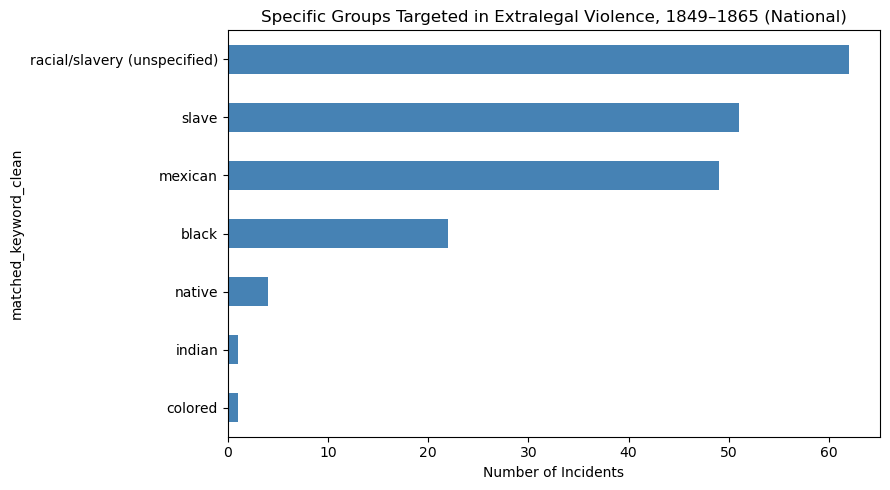

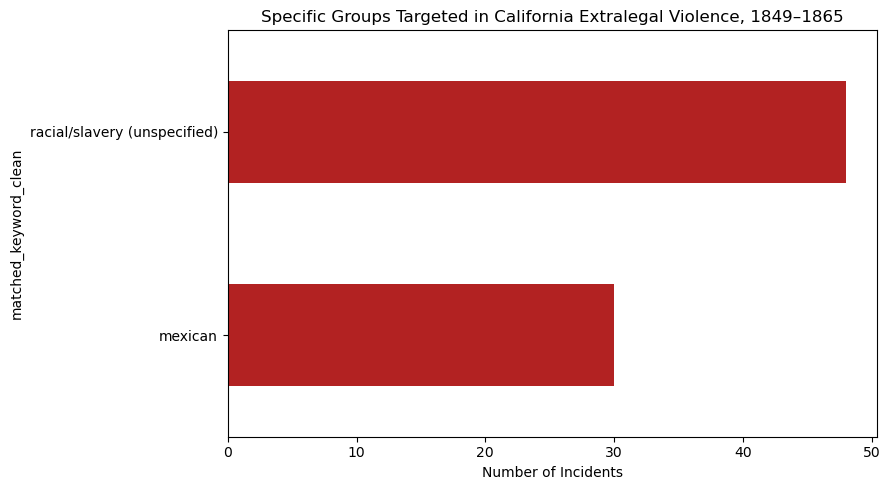

Mexican-related incidents as % of CA racial violence: 38.5%


In [8]:
# -----------------------------
# 5c. Clean up and visualize keyword breakdown
# -----------------------------

# Merge mexico/mexican and indian/indians into single categories
keyword_map = {
    "mexico": "mexican",
    "indians": "indian",
}
df["matched_keyword_clean"] = df["matched_keyword"].replace(keyword_map)

# --- Chart: Specific groups targeted NATIONALLY ---
national_keywords = (
    df[df["matched_keyword_clean"].notna()]
    ["matched_keyword_clean"]
    .value_counts()
)

national_keywords.sort_values().plot(kind="barh", figsize=(9, 5), color="steelblue")
plt.title("Specific Groups Targeted in Extralegal Violence, 1849–1865 (National)")
plt.xlabel("Number of Incidents")
plt.tight_layout()
plt.show()

# --- Chart: California only ---
ca_keywords_clean = (
    df[(df["State"] == "California") & df["matched_keyword_clean"].notna()]
    ["matched_keyword_clean"]
    .value_counts()
)

ca_keywords_clean.sort_values().plot(kind="barh", figsize=(9, 5), color="firebrick")
plt.title("Specific Groups Targeted in California Extralegal Violence, 1849–1865")
plt.xlabel("Number of Incidents")
plt.tight_layout()
plt.show()

# --- Stat to use in your write-up ---
total_ca_racial = df[(df["State"] == "California") & 
                     (df["incident_group"] == "Racial/Slavery-Related")].shape[0]
mexican_ca = df[(df["State"] == "California") & 
                (df["matched_keyword_clean"] == "mexican")].shape[0]

print(f"Mexican-related incidents as % of CA racial violence: "
      f"{mexican_ca/total_ca_racial*100:.1f}%")

### Regional Comparison: Core Finding
The chart below shows the *share* of incidents that were racial within each region.

**Key finding:** The South had ~78% racial violence; the West/North had ~53%. The 25-point gap is a significant difference because most people in the United States believe that the North and South were widely different. But a majority of Northern/Western extralegal violence was still racialized, which directly contradicts the "North as utopia" narrative.

Raw counts by region and incident group:


incident_group,Other,Racial/Slavery-Related
region,,
South/Border South,16,59
West/North,114,131


Percentages within each region:


incident_group,Other,Racial/Slavery-Related
region,,
South/Border South,21.33,78.67
West/North,46.53,53.47


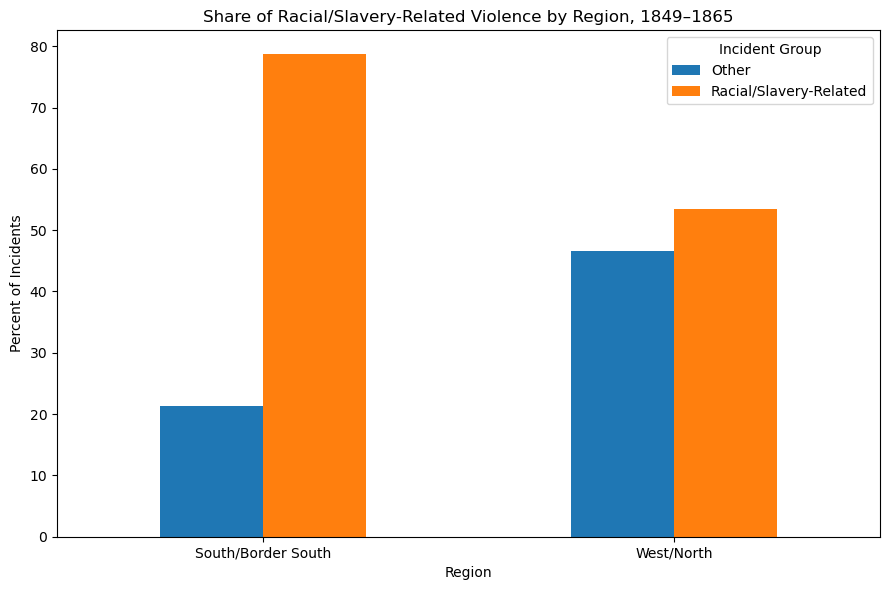

In [9]:
comparison_counts = pd.crosstab(df["region"], df["incident_group"])
comparison_percent = pd.crosstab(
    df["region"], df["incident_group"], normalize="index"
) * 100

print("Raw counts by region and incident group:")
display(comparison_counts)
print("Percentages within each region:")
display(comparison_percent.round(2))

comparison_percent.plot(kind="bar", figsize=(9, 6))
plt.title("Share of Racial/Slavery-Related Violence by Region, 1849–1865")
plt.xlabel("Region")
plt.ylabel("Percent of Incidents")
plt.xticks(rotation=0)
plt.legend(title="Incident Group")
plt.tight_layout()
plt.show()

### State-Level Breakdown
Showing incident counts by state (filtered to states with 4+ incidents for readability). California's prominence — the tallest orange bar — is the most striking visual finding in the dataset and motivates the case study below.

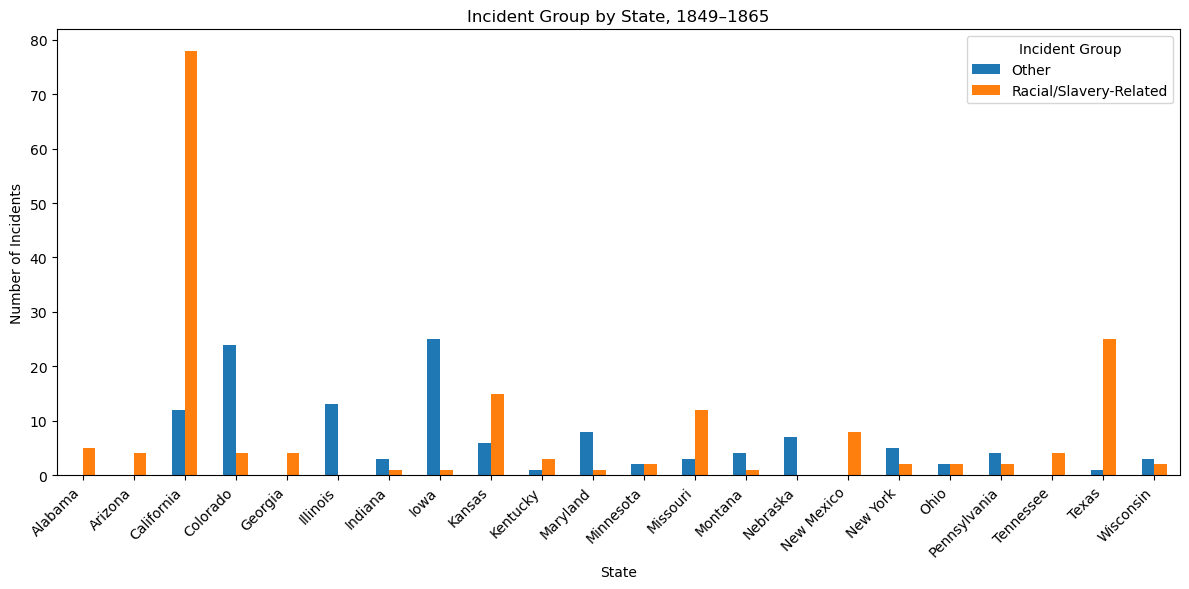

In [10]:
state_counts = pd.crosstab(df["State"], df["incident_group"])
state_counts["total_incidents"] = state_counts.sum(axis=1)
state_counts_filtered = state_counts[state_counts["total_incidents"] >= 4].drop(columns="total_incidents")

state_counts_filtered.plot(kind="bar", figsize=(12, 6))
plt.title("Incident Group by State, 1849–1865")
plt.xlabel("State")
plt.ylabel("Number of Incidents")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Incident Group")
plt.tight_layout()
plt.show()

### California Case Study
California entered the Union in 1850 as a free state. Under the conventional North/South narrative, it should have exhibited low rates of racial violence. Instead it recorded the highest concentration of racial extralegal incidents of any Western state — higher than most slave states in the dataset.

The driving force was not slavery but **settler expansion and Gold Rush competition**: Mexican Californians were dispossessed, criminalized, and killed by Anglo settlers who used extralegal mob action and narratives of frontier lawlessness to justify it.

> **Note:** The 48 "racial/slavery unspecified" incidents in California likely contain additional anti-Mexican violence. The 38.5% Mexican-targeting figure is a floor, not a ceiling.

Total California incidents: 90
Racial/Slavery-Related: 78
Other: 12


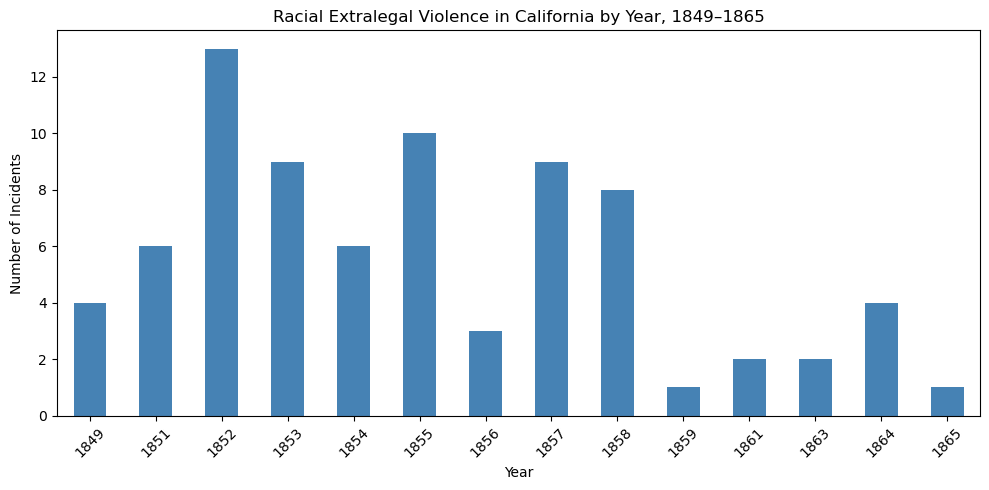

In [11]:
ca_df = df[df["State"] == "California"].copy()

print(f"Total California incidents: {len(ca_df)}")
print(f"Racial/Slavery-Related: {(ca_df['incident_group'] == 'Racial/Slavery-Related').sum()}")
print(f"Other: {(ca_df['incident_group'] == 'Other').sum()}")

ca_racial = ca_df[ca_df["incident_group"] == "Racial/Slavery-Related"]
ca_by_year = ca_racial.groupby("Year").size()

ca_by_year.plot(kind="bar", figsize=(10, 5), color="steelblue")
plt.title("Racial Extralegal Violence in California by Year, 1849–1865")
plt.xlabel("Year")
plt.ylabel("Number of Incidents")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### West/North State Comparison
Ranking all West/North states by number of racial incidents. This situates California within its regional context and shows it is not simply an outlier — it is the most extreme expression of a broader Western pattern.

Racial incidents by state in West/North:


,count
State,
California,78
Kansas,15
New Mexico,8
Arizona,4
Colorado,4
Wisconsin,2
Washington,2
Minnesota,2
Oregon,2


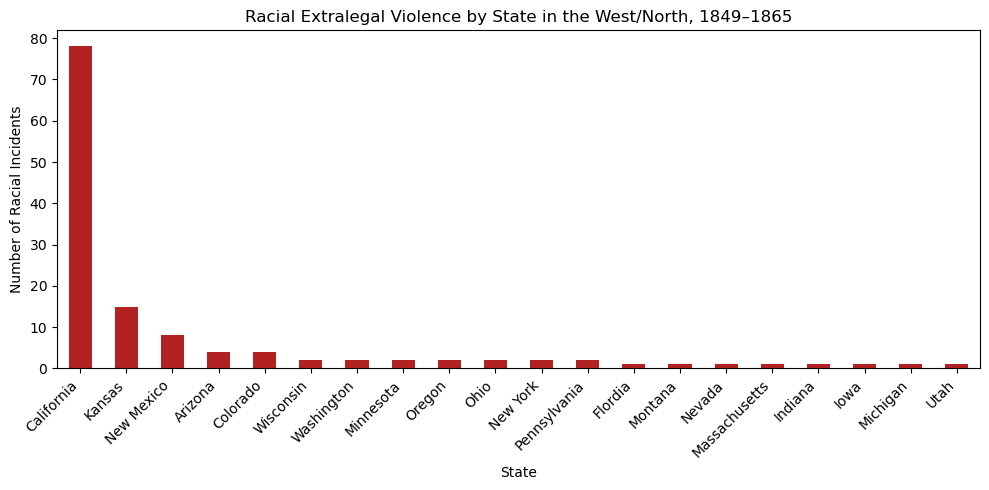

In [12]:
west_north_df = df[df["region"] == "West/North"].copy()

west_state_racial = (
    west_north_df[west_north_df["incident_group"] == "Racial/Slavery-Related"]
    .groupby("State")
    .size()
    .sort_values(ascending=False)
)

print("Racial incidents by state in West/North:")
display(west_state_racial.to_frame("count"))

west_state_racial.plot(kind="bar", figsize=(10, 5), color="firebrick")
plt.title("Racial Extralegal Violence by State in the West/North, 1849–1865")
plt.xlabel("State")
plt.ylabel("Number of Racial Incidents")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

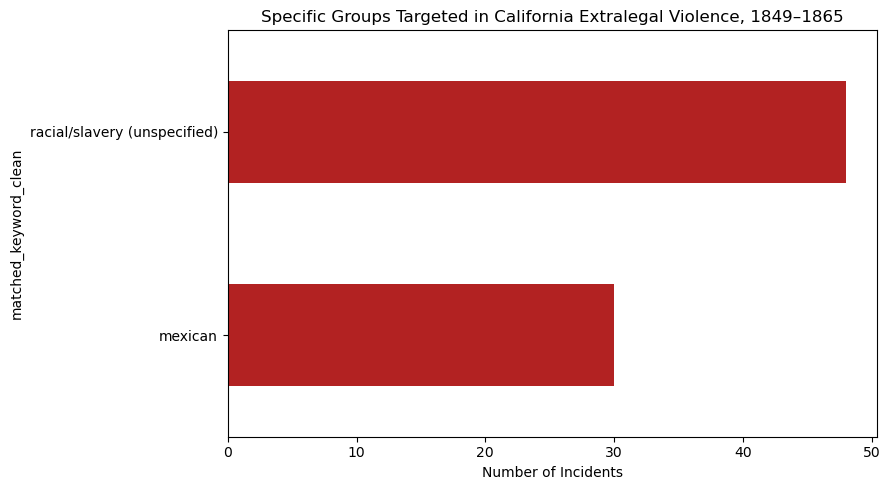

Mexican-related incidents as % of CA racial violence: 38.5%


In [13]:
keyword_map = {"mexico": "mexican", "indians": "indian"}
df["matched_keyword_clean"] = df["matched_keyword"].replace(keyword_map)

ca_keywords_clean = (
    df[(df["State"] == "California") & df["matched_keyword_clean"].notna()]
    ["matched_keyword_clean"]
    .value_counts()
)

ca_keywords_clean.sort_values().plot(kind="barh", figsize=(9, 5), color="firebrick")
plt.title("Specific Groups Targeted in California Extralegal Violence, 1849–1865")
plt.xlabel("Number of Incidents")
plt.tight_layout()
plt.show()

total_ca_racial = df[(df["State"] == "California") &
                     (df["incident_group"] == "Racial/Slavery-Related")].shape[0]
mexican_ca = df[(df["State"] == "California") &
                (df["matched_keyword_clean"] == "mexican")].shape[0]
print(f"Mexican-related incidents as % of CA racial violence: {mexican_ca/total_ca_racial*100:.1f}%")

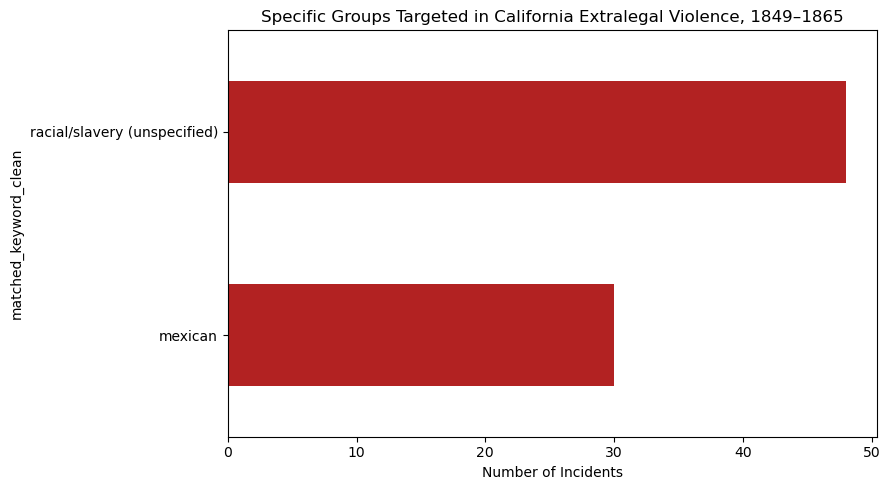

Mexican-related incidents as % of CA racial violence: 38.5%


In [14]:
keyword_map = {"mexico": "mexican", "indians": "indian"}
df["matched_keyword_clean"] = df["matched_keyword"].replace(keyword_map)

ca_keywords_clean = (
    df[(df["State"] == "California") & df["matched_keyword_clean"].notna()]
    ["matched_keyword_clean"]
    .value_counts()
)

ca_keywords_clean.sort_values().plot(kind="barh", figsize=(9, 5), color="firebrick")
plt.title("Specific Groups Targeted in California Extralegal Violence, 1849–1865")
plt.xlabel("Number of Incidents")
plt.tight_layout()
plt.show()

total_ca_racial = df[(df["State"] == "California") &
                     (df["incident_group"] == "Racial/Slavery-Related")].shape[0]
mexican_ca = df[(df["State"] == "California") &
                (df["matched_keyword_clean"] == "mexican")].shape[0]
print(f"Mexican-related incidents as % of CA racial violence: {mexican_ca/total_ca_racial*100:.1f}%")

In [15]:
comparison_counts = pd.crosstab(df["region"], df["incident_group"])
comparison_percent = pd.crosstab(
    df["region"], df["incident_group"], normalize="index"
) * 100

print("Raw counts by region and incident group:")
display(comparison_counts)

print("Percentages within each region:")
display(comparison_percent.round(2))

Raw counts by region and incident group:


incident_group,Other,Racial/Slavery-Related
region,,
South/Border South,16,59
West/North,114,131


Percentages within each region:


incident_group,Other,Racial/Slavery-Related
region,,
South/Border South,21.33,78.67
West/North,46.53,53.47


Total California incidents: 90
Racial/Slavery-Related: 78
Other: 12

Keywords triggering racial classification in California:


,count
matched_keyword,
racial/slavery (unspecified),48
mexican,29
mexico,1


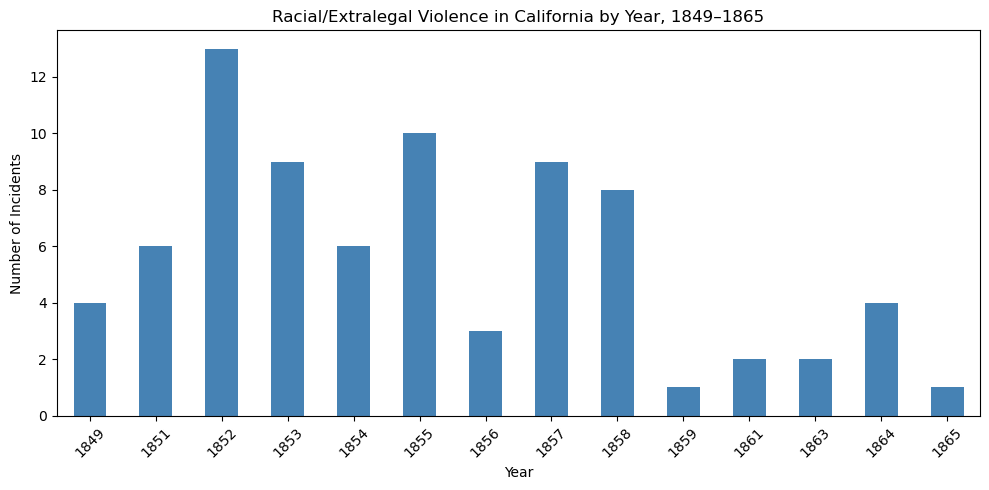


Racial/Slavery-Related incidents by state in West/North:


,count
State,
California,78
Kansas,15
New Mexico,8
Arizona,4
Colorado,4
Wisconsin,2
Washington,2
Minnesota,2
Oregon,2


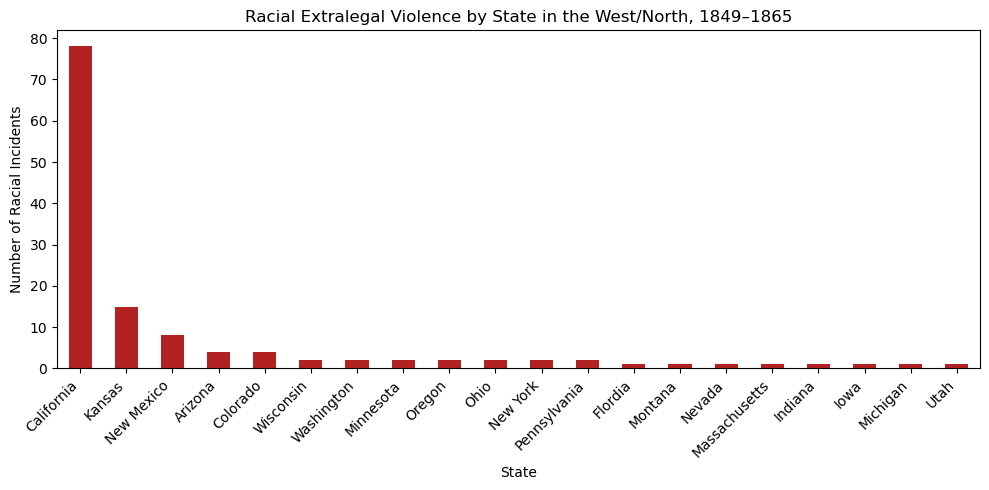


Sample incident descriptions mentioning 'mexican' in California:

Year: 1849 | Type: Racial; Ethnic/National; Religious
Description: Summer: Company of veterans called "the Hounds" attack hispanics from Chile, Peru, and Mexico. At least one killed.
------------------------------------------------------------

Year: 1849 | Type: Vigilante; Law; Racial; Ethnic/National; Religious
Description: December: A Mexican hanged for alleged theft.
------------------------------------------------------------

Year: 1849 | Type: Vigilante; Law; Racial; Ethnic/National; Religious
Description: Late: Unknown Mexican hanged for allegedly stealing a mule.
------------------------------------------------------------

Year: 1851 | Type: Vigilante; Law; Racial; Ethnic/National; Religious
Description: June: Anglo vigilance committee hanged a Mexican man for alleged murder.
------------------------------------------------------------

Year: 1851 | Type: Racial; Law; Vigilante; Ethnic/National; Religious
Desc

In [16]:
# -----------------------------
# 8b. CALIFORNIA DEEP DIVE
# Key finding: California had the most racial extralegal
# violence in the West/North, driven by anti-Mexican violence
# -----------------------------

ca_df = df[df["State"] == "California"].copy()

print(f"Total California incidents: {len(ca_df)}")
print(f"Racial/Slavery-Related: {(ca_df['incident_group'] == 'Racial/Slavery-Related').sum()}")
print(f"Other: {(ca_df['incident_group'] == 'Other').sum()}")

# --- What keywords drove California's racial violence? ---
print("\nKeywords triggering racial classification in California:")
display(
    ca_df[ca_df["matched_keyword"].notna()]["matched_keyword"]
    .value_counts()
    .to_frame("count")
)

# --- California racial violence over time ---
ca_racial = ca_df[ca_df["incident_group"] == "Racial/Slavery-Related"]
ca_by_year = ca_racial.groupby("Year").size()

ca_by_year.plot(kind="bar", figsize=(10, 5), color="steelblue")
plt.title("Racial/Extralegal Violence in California by Year, 1849–1865")
plt.xlabel("Year")
plt.ylabel("Number of Incidents")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- Compare California to other West/North states ---
west_north_df = df[df["region"] == "West/North"].copy()

west_state_racial = (
    west_north_df[west_north_df["incident_group"] == "Racial/Slavery-Related"]
    .groupby("State")
    .size()
    .sort_values(ascending=False)
)

print("\nRacial/Slavery-Related incidents by state in West/North:")
display(west_state_racial.to_frame("count"))

west_state_racial.plot(kind="bar", figsize=(10, 5), color="firebrick")
plt.title("Racial Extralegal Violence by State in the West/North, 1849–1865")
plt.xlabel("State")
plt.ylabel("Number of Racial Incidents")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# --- Sample descriptions from California Mexican-related incidents ---
print("\nSample incident descriptions mentioning 'mexican' in California:")
mexican_ca = ca_df[ca_df["matched_keyword"].isin(["mexican", "mexico"])]
for i, row in mexican_ca.head(5).iterrows():
    print(f"\nYear: {row['Year']} | Type: {row['Type']}")
    print(f"Description: {row['Description'][:300]}")
    print("-" * 60)

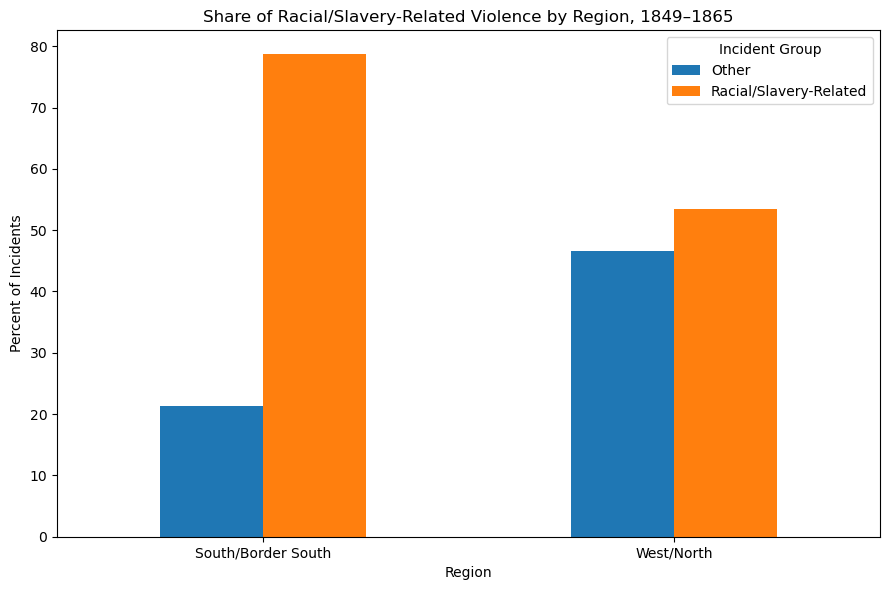

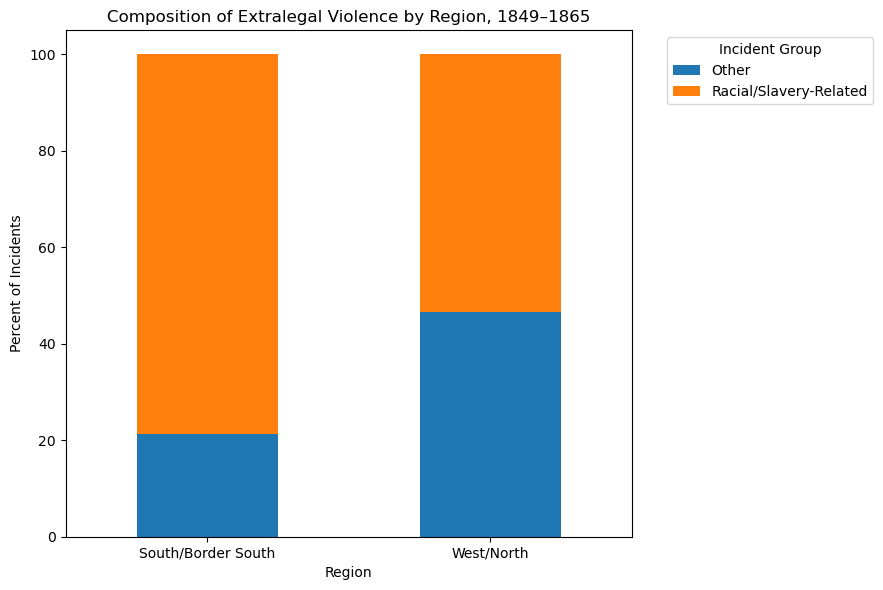

In [17]:
comparison_percent.plot(kind="bar", figsize=(9, 6))
plt.title("Share of Racial/Slavery-Related Violence by Region, 1849–1865")
plt.xlabel("Region")
plt.ylabel("Percent of Incidents")
plt.xticks(rotation=0)
plt.legend(title="Incident Group")
plt.tight_layout()
plt.show()

comparison_percent.plot(kind="bar", stacked=True, figsize=(9, 6))
plt.title("Composition of Extralegal Violence by Region, 1849–1865")
plt.xlabel("Region")
plt.ylabel("Percent of Incidents")
plt.xticks(rotation=0)
plt.legend(title="Incident Group", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

State-level counts (states with at least 4 incidents):


incident_group,Other,Racial/Slavery-Related
State,,
Iowa,25,1
Colorado,24,4
Illinois,13,0
California,12,78
Maryland,8,1
Nebraska,7,0
Kansas,6,15
New York,5,2
Pennsylvania,4,2


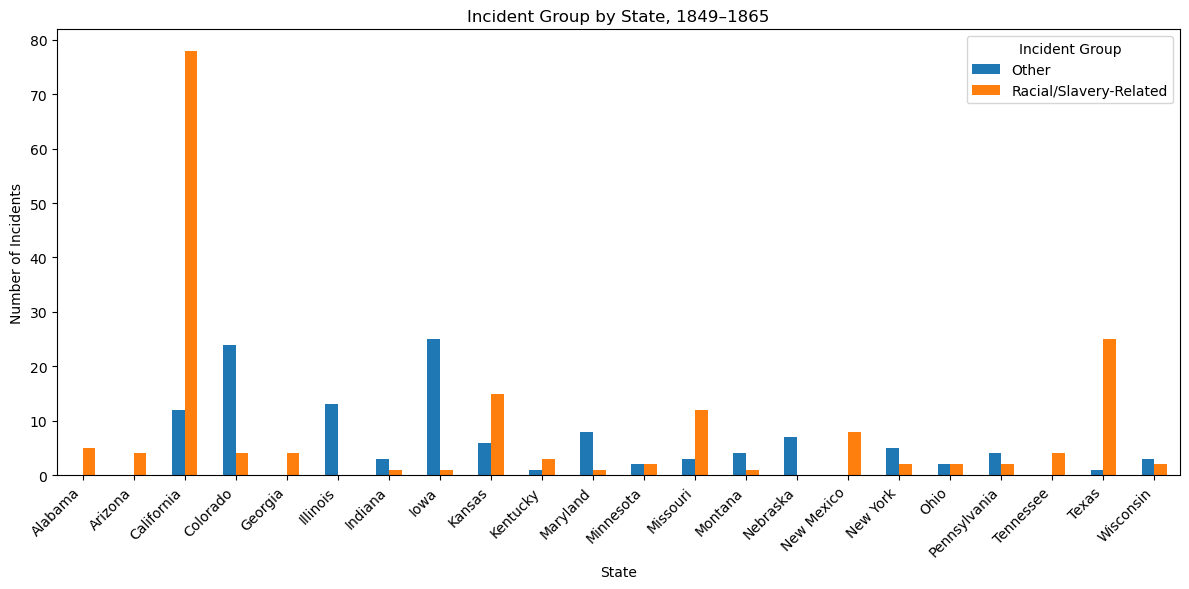

In [18]:
state_counts = pd.crosstab(df["State"], df["incident_group"])
state_counts["total_incidents"] = state_counts.sum(axis=1)

state_counts_filtered = state_counts[state_counts["total_incidents"] >= 4].drop(
    columns="total_incidents"
)

print("State-level counts (states with at least 4 incidents):")
display(state_counts_filtered.sort_values(
    by=state_counts_filtered.columns.tolist(),
    ascending=False
))

state_counts_filtered.plot(kind="bar", figsize=(12, 6))
plt.title("Incident Group by State, 1849–1865")
plt.xlabel("State")
plt.ylabel("Number of Incidents")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Incident Group")
plt.tight_layout()
plt.show()

This graph clearly shows that California has the highest number of racial/slavery-related violence when California only became an official state in 1850. California’s prominence in the dataset highlights how frontier regions could produce intense racial violence, but it does not overturn the broader regional pattern. 

How many times have we studied the Civil War and its repercussions and left thinking that South=bad side, North=good side?


### Temporal Analysis: How Violence Changed Over Time
The dataset spans two distinct political periods: **1849–1860** (antebellum, rising sectional tension) and **1861–1865** (Civil War). The analysis below examines whether the *proportion* and *vocabulary* of racial violence shifted across these periods.

The expectation — that war would redirect violence toward military aims and reduce extralegal racial killing — is not clearly supported by the data.

Percentages by time period:


incident_group,Other,Racial/Slavery-Related
period,,
1849–1860,33.75,66.25
1861–1865,61.25,38.75


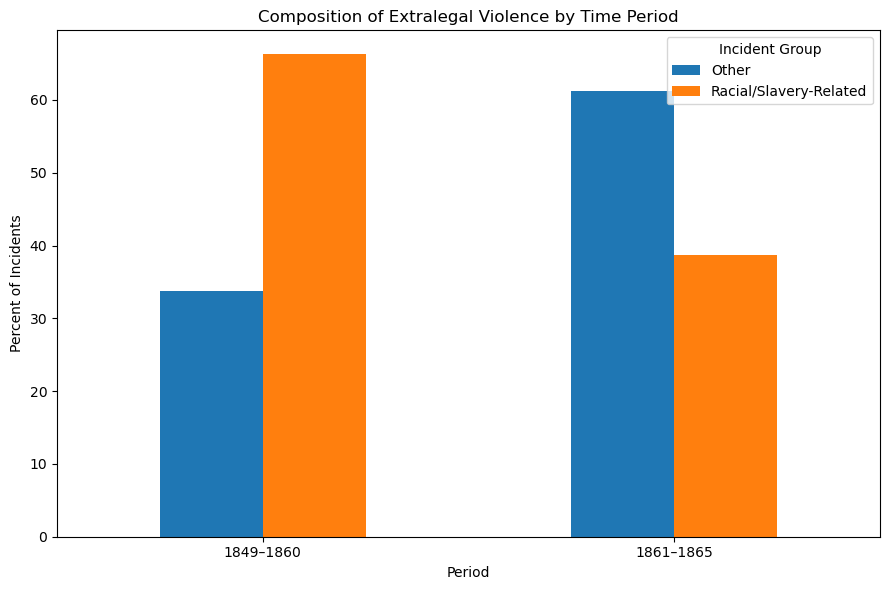

In [19]:
def assign_period(year):
    if year <= 1860:
        return "1849–1860"
    return "1861–1865"

df["period"] = df["Year"].apply(assign_period)

period_percent = pd.crosstab(df["period"], df["incident_group"], normalize="index") * 100

print("Percentages by time period:")
display(period_percent.round(2))

period_percent.plot(kind="bar", figsize=(9, 6))
plt.title("Composition of Extralegal Violence by Time Period")
plt.xlabel("Period")
plt.ylabel("Percent of Incidents")
plt.xticks(rotation=0)
plt.legend(title="Incident Group")
plt.tight_layout()
plt.show()

### Probabilistic Model: Regional and State-Level Probabilities
Converting the classification to a binary variable (1 = Racial/Slavery-Related, 0 = Other) and computing the mean by region and state gives the *probability* that any given incident in that region/state was racial in nature. This is the cleanest way to compare across regions with different total incident counts.

Probability of racial/slavery-related incident by region:


,probability
region,
South/Border South,0.786667
West/North,0.534694


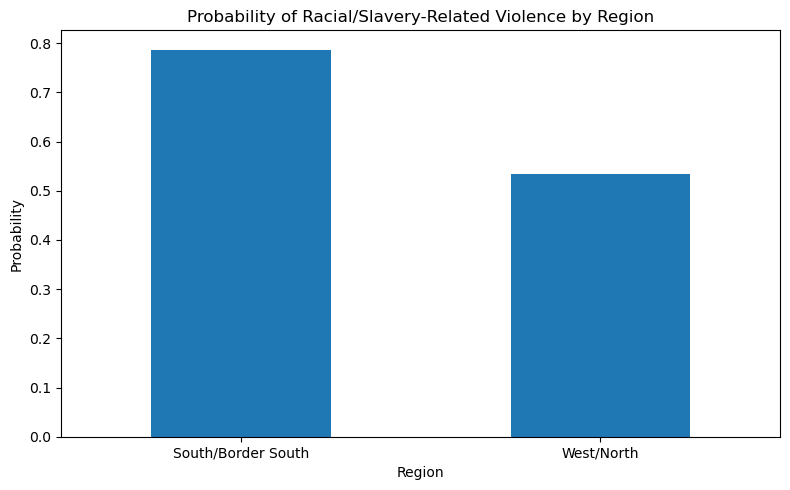

In [20]:
df["target_binary"] = df["incident_group"].apply(
    lambda x: 1 if x == "Racial/Slavery-Related" else 0
)

region_prob = df.groupby("region")["target_binary"].mean().sort_values(ascending=False)

print("Probability of racial/slavery-related incident by region:")
display(region_prob.to_frame("probability"))

region_prob.plot(kind="bar", figsize=(8, 5))
plt.title("Probability of Racial/Slavery-Related Violence by Region")
plt.xlabel("Region")
plt.ylabel("Probability")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

States with the highest probability of racial/slavery-related incidents:


,probability,count
State,,
Alabama,1.000000,5
Arizona,1.000000,4
Georgia,1.000000,4
Tennessee,1.000000,4
New Mexico,1.000000,8
Texas,0.961538,26
California,0.866667,90
Missouri,0.800000,15
Kentucky,0.750000,4


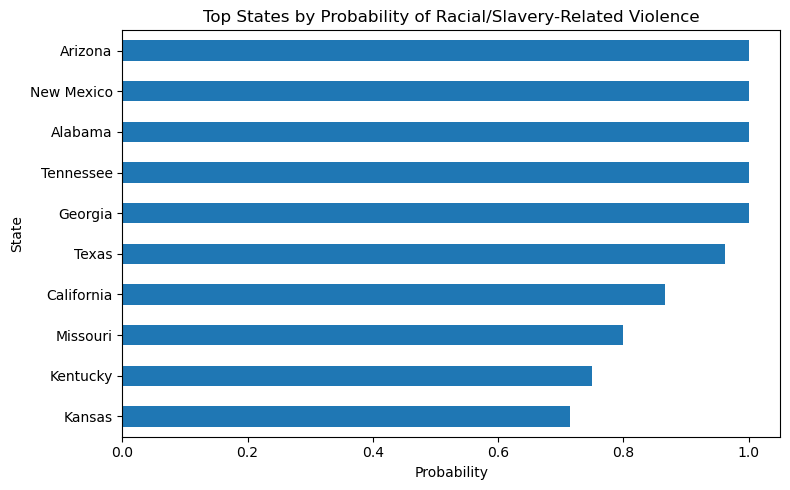

In [21]:
state_prob = df.groupby("State")["target_binary"].mean()
state_count = df.groupby("State").size()

state_summary = pd.DataFrame({
    "probability": state_prob,
    "count": state_count
})

state_summary = state_summary[state_summary["count"] >= 4]
state_summary = state_summary.sort_values("probability", ascending=False)

print("States with the highest probability of racial/slavery-related incidents:")
display(state_summary.head(10))

state_summary.head(10)["probability"].sort_values().plot(kind="barh", figsize=(8, 5))
plt.title("Top States by Probability of Racial/Slavery-Related Violence")
plt.xlabel("Probability")
plt.tight_layout()
plt.show()

### Target Classification Probabilities
Breaking down probabilities by victim/target classification. This surfaces which victim profiles were most consistently associated with racial extralegal violence — and reveals the role of criminalization labels ("alleged murderer," "alleged criminal") in legitimizing the killings.

Target classifications most associated with racial/slavery-related violence:


,probability,count
Target Classification,,
Free-Soiler; Anti-Slavery; Free-Stater,1.000000,5
Black; Slave; Alleged Criminal; Alleged Sexual Assailant,1.000000,3
Black; Slave; Alleged Criminal; Alleged Murderer,1.000000,5
Mexican; Hispanic; Catholic; Alleged Criminal; Alleged Murderer; Legal; Jail; Prisoner,1.000000,4
Mexican; Hispanic; Catholic; Alleged Criminal; Alleged Thief,1.000000,10
Mexican; Hispanic; Catholic; Alleged Criminal; Alleged Murderer;,1.000000,3
Mexican; Hispanic; Catholic,1.000000,6
Mexican; Hispanic; Catholic; Alleged Murderer; Alleged Criminal,1.000000,3
Mexican; Hispanic; Catholic; Alleged Criminal; Alleged Murderer,0.977778,45


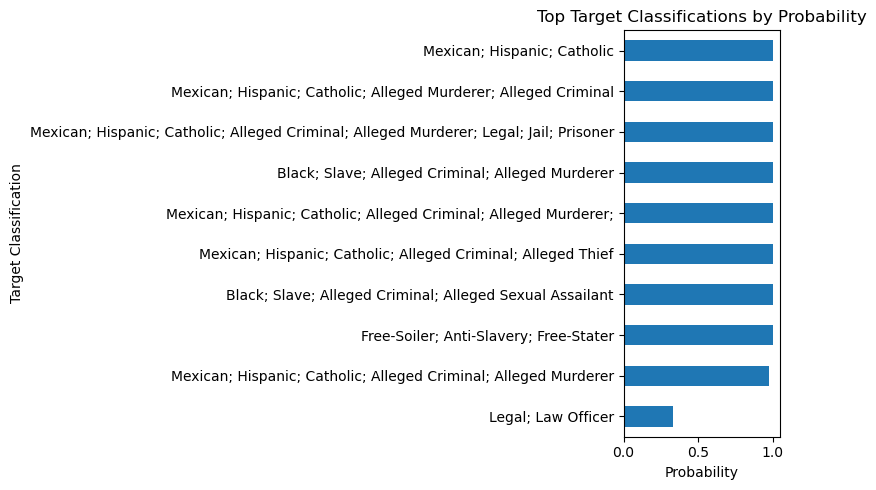

In [22]:
if "Target Classification" in df.columns:
    target_prob = df.groupby("Target Classification")["target_binary"].mean()
    target_count = df.groupby("Target Classification").size()

    target_summary = pd.DataFrame({
        "probability": target_prob,
        "count": target_count
    })

    target_summary = target_summary[target_summary["count"] >= 3]
    target_summary = target_summary.sort_values("probability", ascending=False)

    print("Target classifications most associated with racial/slavery-related violence:")
    display(target_summary.head(10))

    target_summary.head(10)["probability"].sort_values().plot(kind="barh", figsize=(8, 5))
    plt.title("Top Target Classifications by Probability")
    plt.xlabel("Probability")
    plt.tight_layout()
    plt.show()

### NLP Analysis: The Language of Extralegal Violence
Tokenizing and analyzing the free-text `Description` field to identify the most frequent words associated with racial vs. non-racial incidents.

> **Methodological note:** Stopwords are removed manually. The appearance of "alleged" as the single most frequent term is analytically significant: it reveals that extralegal violence was almost always justified through accusation, however unverified. Perpetrators framed themselves as acting in the *absence* of law, not in defiance of it. This logic was not exclusively Southern — it was available everywhere the dataset records violence.

In [23]:
stopwords = {
    "the", "a", "an", "and", "or", "of", "to", "in", "on", "for", "by",
    "with", "was", "were", "is", "are", "at", "as", "from", "that", "this",
    "it", "his", "her", "their", "them", "he", "she", "they", "after",
    "before", "when", "into", "out", "then", "than", "had", "has", "have",
    "be", "been", "being", "who", "which", "also", "not", "but", "one",
    "two", "three", "said", "would", "there", "about", "upon", "january",
    "february", "march", "april", "may", "june", "july", "august",
    "september", "october", "november", "december", "men", "man"
}

def tokenize(text):
    words = re.findall(r"\b[a-z]+\b", str(text).lower())
    return [word for word in words if word not in stopwords and len(word) > 2]

def top_words(series, n=12):
    all_words = []
    for text in series.dropna():
        all_words.extend(tokenize(text))
    if len(all_words) == 0:
        return pd.Series(dtype=int)
    return pd.Series(all_words).value_counts().head(n)

Top words in racial/slavery-related descriptions:


,count
alleged,112
murder,84
lynched,58
hanged,55
mexican,36
black,34
unknown,32
killed,29
enslaved,29
hanging,24


Top words in other descriptions:


,count
alleged,45
killed,36
him,33
horse,31
hanged,28
lynched,24
murder,23
vigilantes,21
theft,19
court,19


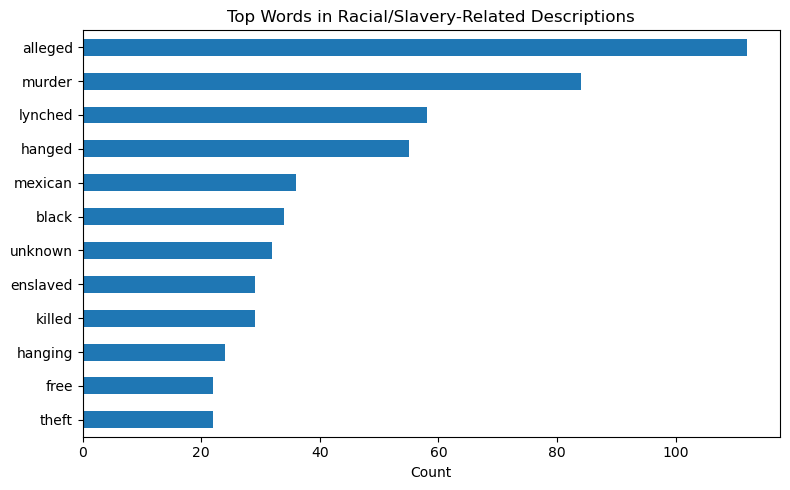

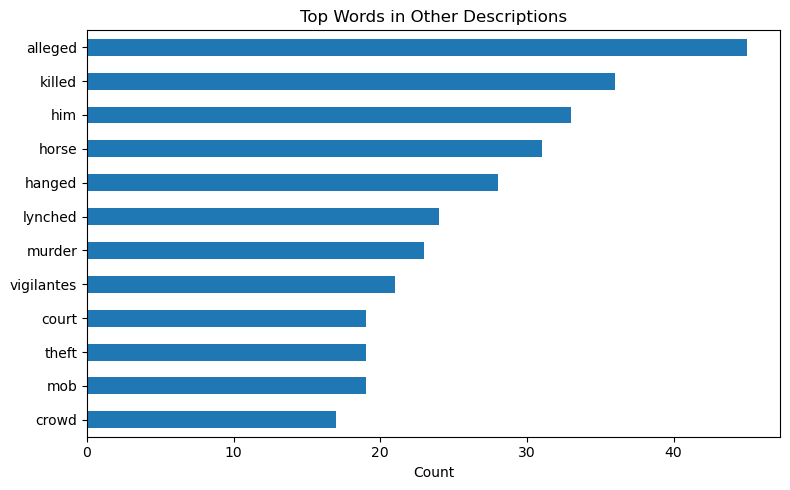

In [24]:
racial_words = top_words(df[df["incident_group"] == "Racial/Slavery-Related"]["Description"])
other_words = top_words(df[df["incident_group"] == "Other"]["Description"])

print("Top words in racial/slavery-related descriptions:")
display(racial_words.to_frame("count"))

print("Top words in other descriptions:")
display(other_words.to_frame("count"))

if len(racial_words) > 0:
    racial_words.sort_values().plot(kind="barh", figsize=(8, 5))
    plt.title("Top Words in Racial/Slavery-Related Descriptions")
    plt.xlabel("Count")
    plt.tight_layout()
    plt.show()

if len(other_words) > 0:
    other_words.sort_values().plot(kind="barh", figsize=(8, 5))
    plt.title("Top Words in Other Descriptions")
    plt.xlabel("Count")
    plt.tight_layout()
    plt.show()

### Period-Specific Vocabulary
Comparing words unique to each time period reveals how the political context of the 1850s (free soil, Mexican targets, regulators) shifted during the war years. This is a form of distant reading — using word frequency to track historical change without reading every document individually.

The probability distribution of target classifications reveals that victims of extralegal violence were defined not only by race but also by accusations of criminality. Mexican and Hispanic victims are frequently labeled as alleged criminals or murderers, suggesting that racial violence in the West was often justified through narratives of lawlessness. This differs slightly from Southern patterns, where Black victims are more directly tied to slavery and racial control. Together, these patterns suggest that extralegal violence operated through both racial and legal frameworks, varying by region.

Most common words in 1849–1860 descriptions:


,count
alleged,122
murder,92
hanged,65
lynched,58
killed,46
hanging,33
unknown,31
committee,30
him,29
horse,28


Most common words in 1861–1865 descriptions:


,count
alleged,35
lynched,24
killed,19
black,19
hanged,18
theft,16
murder,15
him,13
mob,12
vigilantes,12


Words unique to 1849–1860:


,count
free,23
mexicans,16
regulators,12
slavery,12
house,12
soil,11
four,11
fire,10
election,10
company,9


Words unique to 1861–1865:


,count
draft,6
minter,5
iler,4
conroy,4
frank,3
fox,3
provost,3
military,3
enrolling,3
bouve,3


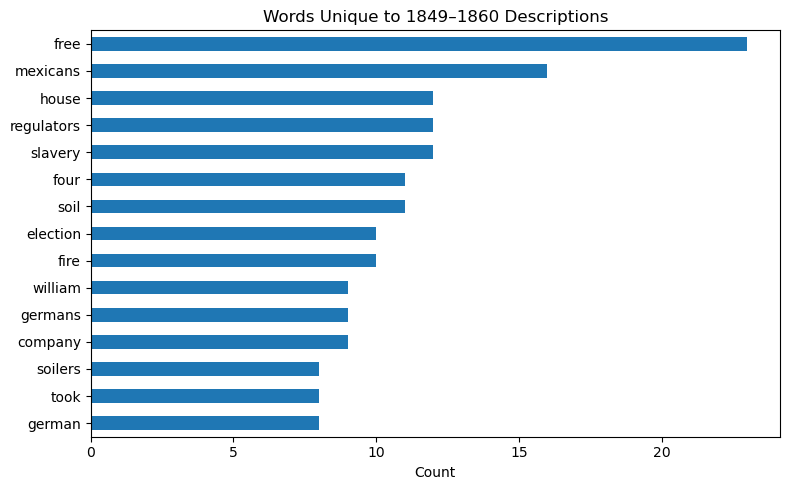

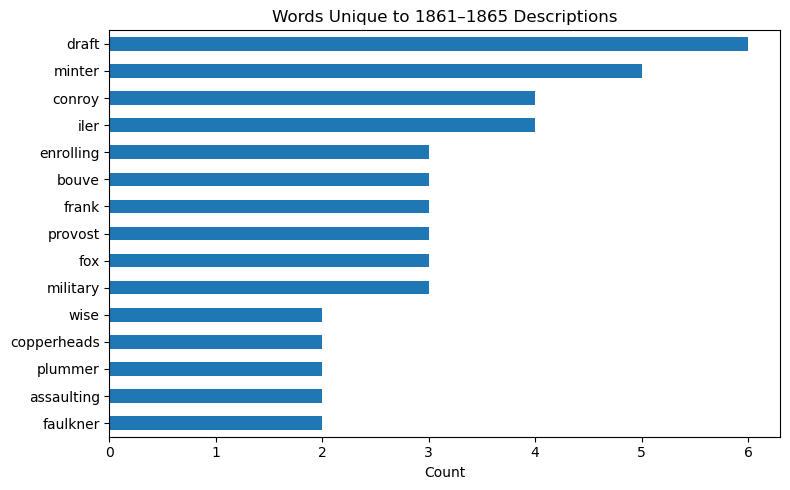

In [25]:

prewar_text = " ".join(df[df["period"] == "1849–1860"]["Description"].dropna())
war_text = " ".join(df[df["period"] == "1861–1865"]["Description"].dropna())

prewar_words = tokenize(prewar_text)
war_words = tokenize(war_text)

prewar_freq = pd.Series(prewar_words).value_counts()
war_freq = pd.Series(war_words).value_counts()

print("Most common words in 1849–1860 descriptions:")
display(prewar_freq.head(15).to_frame("count"))

print("Most common words in 1861–1865 descriptions:")
display(war_freq.head(15).to_frame("count"))

prewar_unique = prewar_freq[~prewar_freq.index.isin(war_freq.index)].head(15)
war_unique = war_freq[~war_freq.index.isin(prewar_freq.index)].head(15)

print("Words unique to 1849–1860:")
display(prewar_unique.to_frame("count"))

print("Words unique to 1861–1865:")
display(war_unique.to_frame("count"))

if len(prewar_unique) > 0:
    prewar_unique.sort_values().plot(kind="barh", figsize=(8, 5))
    plt.title("Words Unique to 1849–1860 Descriptions")
    plt.xlabel("Count")
    plt.tight_layout()
    plt.show()

if len(war_unique) > 0:
    war_unique.sort_values().plot(kind="barh", figsize=(8, 5))
    plt.title("Words Unique to 1861–1865 Descriptions")
    plt.xlabel("Count")
    plt.tight_layout()
    plt.show()

Average recorded deaths by incident group:


,avg_recorded_killed
incident_group,
Other,2.49
Racial/Slavery-Related,3.05


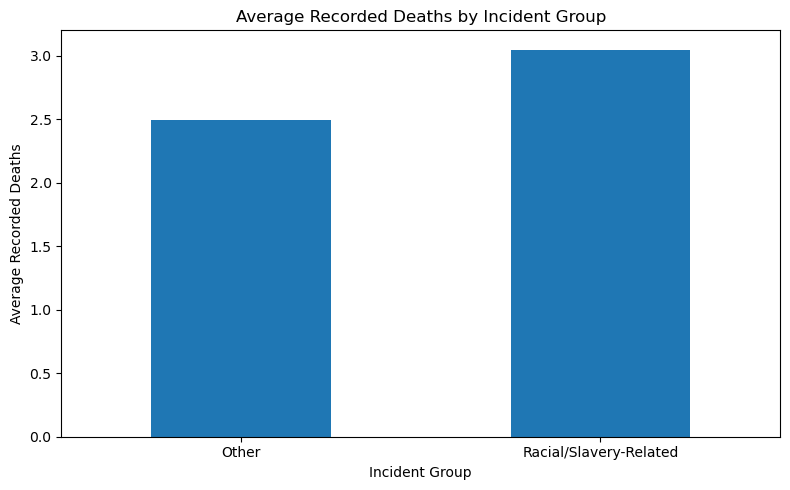

In [26]:
if "Recorded # Killed" in df.columns:
    severity = df.groupby("incident_group")["Recorded # Killed"].mean().dropna()

    print("Average recorded deaths by incident group:")
    display(severity.round(2).to_frame("avg_recorded_killed"))

    if len(severity) > 0:
        severity.plot(kind="bar", figsize=(8, 5))
        plt.title("Average Recorded Deaths by Incident Group")
        plt.xlabel("Incident Group")
        plt.ylabel("Average Recorded Deaths")
        plt.xticks(rotation=0)
        plt.tight_layout()
        plt.show()

### Export Cleaned Dataset
Saving the cleaned and classified dataset as a CSV for reproducibility. Any researcher who downloads this repository can load this file and verify or extend the analysis without re-running all cleaning steps.

In [27]:
df.to_csv("cleaned_killings_1849_1865.csv", index=False)
print("Saved cleaned dataset as 'cleaned_killings_1849_1865.csv'")

Saved cleaned dataset as 'cleaned_killings_1849_1865.csv'


---
## Section 2: Continuity — Violence After the Civil War

The Civil War did not end racialized extralegal violence. It transformed it. This section uses two additional datasets to test whether the geographic pattern identified in Section 1 persisted after 1865.

**Datasets:**
- `historical-american-lynching.csv` — post-Civil War lynching records (zipped in `archive (1).zip`)
- `anti_chinese_violence.csv` — lethal anti-Chinese violence, 1850–1910 (Mason, antichineseviolence.com)

**Data cleaning notes:**
- The lynching dataset's `year` column is stored as a string — it must be converted to integer before filtering. Rows with unparseable years are dropped.
- The anti-Chinese dataset uses a messy date format (`"1852 06 ??"`, `"unknown"`, `"1850s early"`). Only rows with a clean 4-digit year at the *start* of the date string are retained using regex `r'^(\d{4})'`. This means early incidents (pre-1855) are undercounted — the true numbers of early anti-Chinese violence are higher than what the time series shows.

Lynching records (post-1865): 2805
Anti-Chinese records: 813
Chinese year range: 1850 – 1903

Lynching by region:
region
South/Border South    100.0
Name: proportion, dtype: float64

Anti-Chinese by region:
region
West/North            99.5
South/Border South     0.5
Name: proportion, dtype: float64


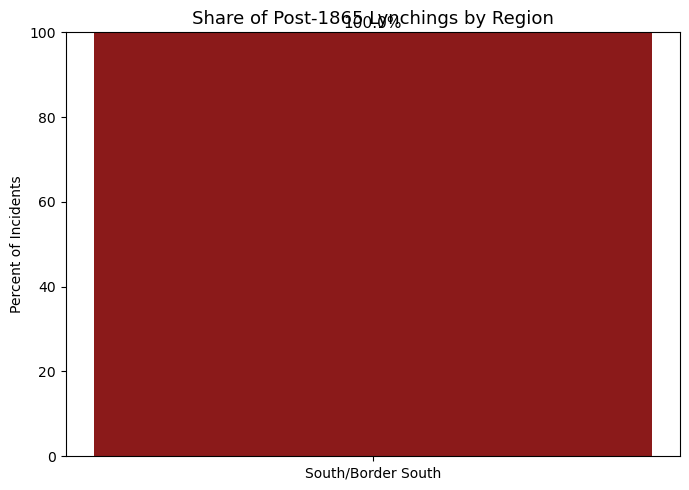

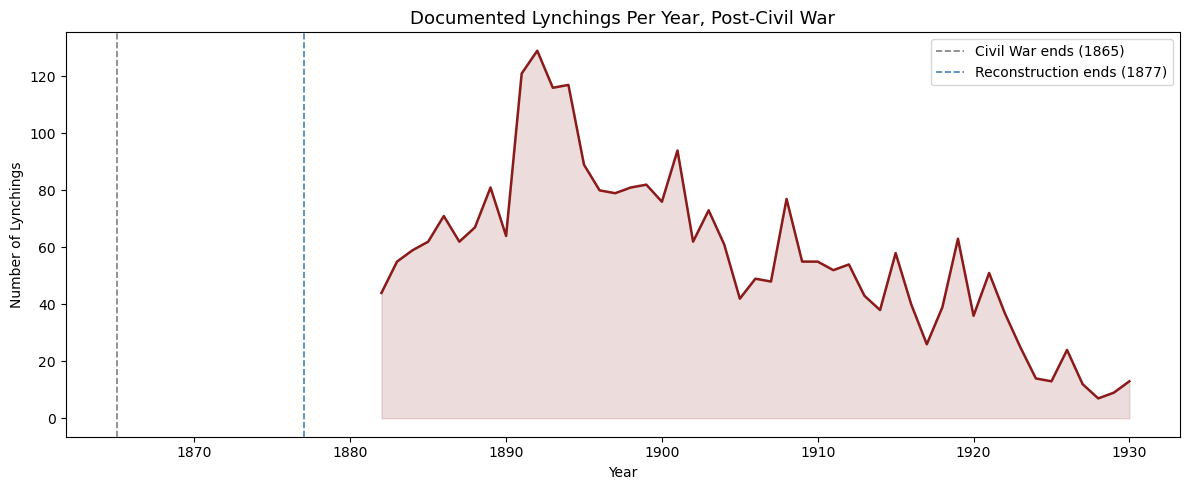

Peak lynching year: 1892 (129 incidents)
Lynchings 1865–1877 (Reconstruction): 0
Lynchings 1878–1900 (post-Reconstruction): 1535


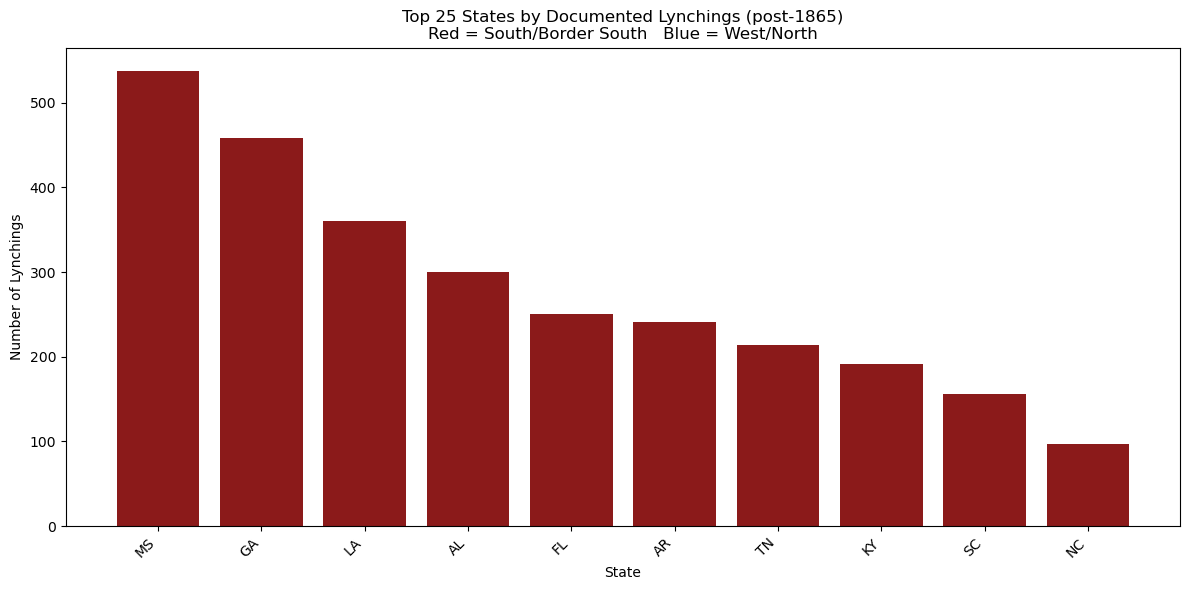

Non-Southern states in top 25:
Series([], Name: lynchings, dtype: int64)


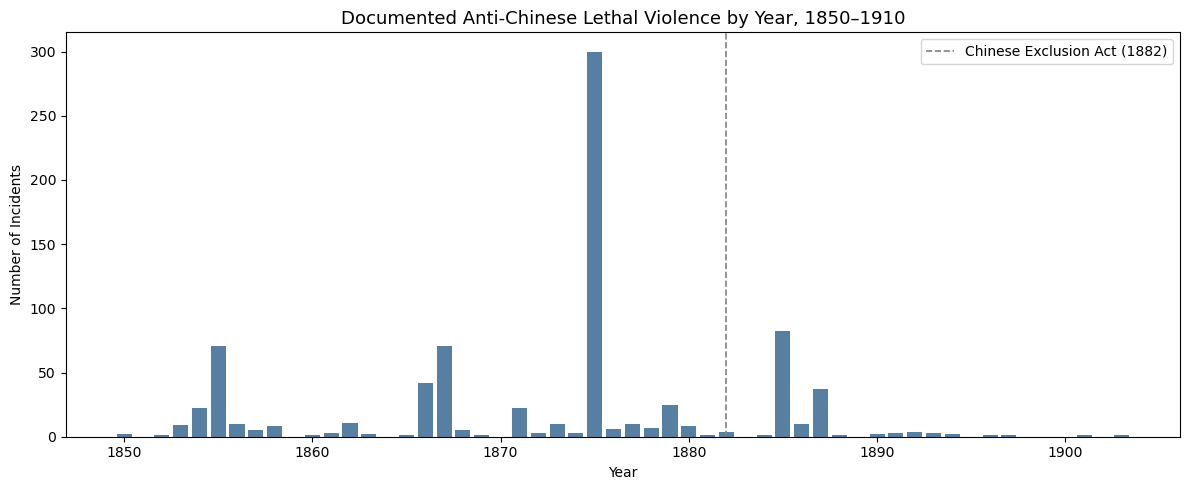

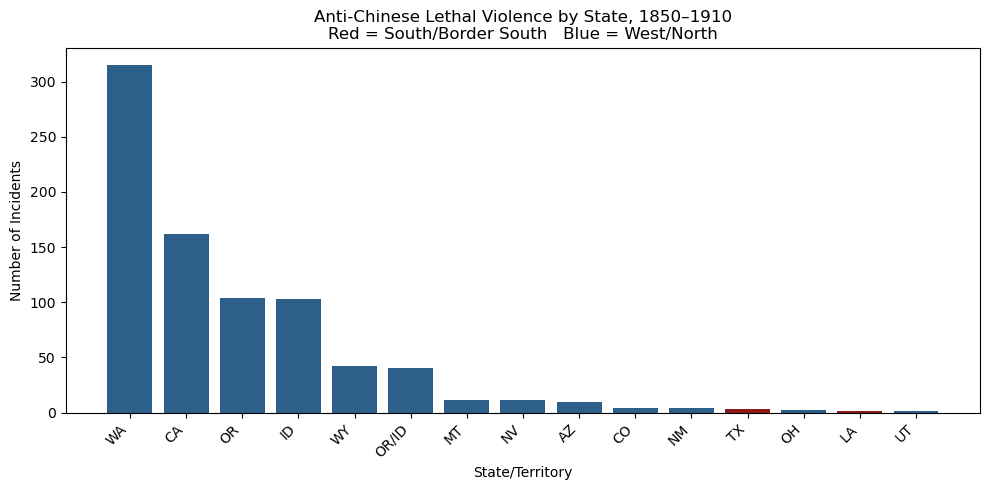


Top states for anti-Chinese violence:
state
WA       315
CA       162
OR       104
ID       103
WY        42
OR/ID     40
MT        11
NV        11
AZ        10
CO         4
NM         4
TX         3
OH         2
LA         1
UT         1
dtype: int64

=== BRIDGE: Three Datasets, One Argument ===
1849–1865: West/North racial incidents = 131 (53.5% of West/North total)
Post-1865 lynching: West/North = 0.0% of all lynchings
Anti-Chinese violence: West/North = 99.5% of all incidents

Across all three datasets, the West/North consistently
produced significant racialized extralegal violence —
disproving the 'North as utopia' narrative at every period.


In [28]:
# ============================================================
# SECTION 2: LYNCHING + ANTI-CHINESE VIOLENCE ANALYSIS
# ============================================================
import pandas as pd
import matplotlib.pyplot as plt
import zipfile

# ---- LOAD LYNCHING DATA ----
with zipfile.ZipFile("archive (1).zip", 'r') as zip_ref:
    zip_ref.extractall("lynching_data")

lynch = pd.read_csv("lynching_data/historical-american-lynching.csv")
lynch.columns = lynch.columns.str.lower().str.strip()
lynch['lynchings'] = 1
lynch['year'] = pd.to_numeric(lynch['year'], errors='coerce')
lynch = lynch.dropna(subset=['year'])
lynch['year'] = lynch['year'].astype(int)
lynch_post = lynch[lynch['year'] >= 1865].copy()

# ---- LOAD ANTI-CHINESE DATA ----
chinese = pd.read_csv("anti_chinese_violence.csv")
chinese.columns = chinese.columns.str.lower().str.strip()
chinese = chinese.rename(columns={
    'date (yyyy mm dd)': 'date',
    'state/territory': 'state'
})
chinese['year'] = chinese['date'].astype(str).str.extract(r'^(\d{4})')
chinese['year'] = pd.to_numeric(chinese['year'], errors='coerce')
chinese = chinese.dropna(subset=['year'])
chinese['year'] = chinese['year'].astype(int)

print(f"Lynching records (post-1865): {len(lynch_post)}")
print(f"Anti-Chinese records: {len(chinese)}")
print(f"Chinese year range: {chinese['year'].min()} – {chinese['year'].max()}")

# ---- ASSIGN REGIONS ----
SOUTH_ABBREV = {
    'AL','AR','FL','GA','KY','LA','MS','MO','NC','SC','TN','TX','VA','WV','DE','MD','OK'
}

lynch_post['region'] = lynch_post['state'].apply(
    lambda x: 'South/Border South' if str(x).upper() in SOUTH_ABBREV else 'West/North'
)
chinese['region'] = chinese['state'].apply(
    lambda x: 'South/Border South' if str(x).upper() in SOUTH_ABBREV else 'West/North'
)

print("\nLynching by region:")
print((lynch_post['region'].value_counts(normalize=True) * 100).round(1))
print("\nAnti-Chinese by region:")
print((chinese['region'].value_counts(normalize=True) * 100).round(1))

# ---- CHART 1: % lynchings by region ----
region_pct = lynch_post['region'].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(region_pct.index, region_pct.values, color=['#8B1A1A', '#2C5F8A'])
ax.set_title("Share of Post-1865 Lynchings by Region", fontsize=13)
ax.set_ylabel("Percent of Incidents")
ax.set_ylim(0, 100)
for bar, val in zip(bars, region_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f"{val:.1f}%", ha='center', fontsize=11)
plt.tight_layout()
plt.savefig("fig_lynching_region_pct.png", dpi=150)
plt.show()

# ---- CHART 2: Lynching time series ----
year_series = lynch_post.groupby('year')['lynchings'].sum()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(year_series.index, year_series.values, color='#8B1A1A', linewidth=1.8)
ax.fill_between(year_series.index, year_series.values, alpha=0.15, color='#8B1A1A')
ax.axvline(x=1865, color='gray', linestyle='--', linewidth=1.2, label='Civil War ends (1865)')
ax.axvline(x=1877, color='steelblue', linestyle='--', linewidth=1.2, label='Reconstruction ends (1877)')
ax.set_title("Documented Lynchings Per Year, Post-Civil War", fontsize=13)
ax.set_xlabel("Year")
ax.set_ylabel("Number of Lynchings")
ax.legend()
plt.tight_layout()
plt.savefig("fig_lynching_timeseries.png", dpi=150)
plt.show()

peak_year = year_series.idxmax()
print(f"Peak lynching year: {peak_year} ({year_series[peak_year]} incidents)")
print(f"Lynchings 1865–1877 (Reconstruction): {year_series.loc[1865:1877].sum()}")
print(f"Lynchings 1878–1900 (post-Reconstruction): {year_series.loc[1878:1900].sum()}")

# ---- CHART 3: State breakdown (lynching) ----
state_totals = lynch_post.groupby('state')['lynchings'].sum().sort_values(ascending=False).head(25)
colors = ['#8B1A1A' if str(s).upper() in SOUTH_ABBREV else '#2C5F8A' for s in state_totals.index]

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(state_totals.index, state_totals.values, color=colors)
ax.set_title("Top 25 States by Documented Lynchings (post-1865)\nRed = South/Border South   Blue = West/North", fontsize=12)
ax.set_xlabel("State")
ax.set_ylabel("Number of Lynchings")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("fig_lynching_states.png", dpi=150)
plt.show()

non_south = state_totals[[s for s in state_totals.index if str(s).upper() not in SOUTH_ABBREV]]
print("Non-Southern states in top 25:")
print(non_south)

# ---- CHART 4: Anti-Chinese violence over time ----
chinese_by_year = chinese.groupby('year').size()

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(chinese_by_year.index, chinese_by_year.values, color='#2C5F8A', alpha=0.8)
ax.axvline(x=1882, color='gray', linestyle='--', linewidth=1.2, label='Chinese Exclusion Act (1882)')
ax.set_title("Documented Anti-Chinese Lethal Violence by Year, 1850–1910", fontsize=13)
ax.set_xlabel("Year")
ax.set_ylabel("Number of Incidents")
ax.legend()
plt.tight_layout()
plt.savefig("fig_chinese_timeseries.png", dpi=150)
plt.show()

# ---- CHART 5: Anti-Chinese violence by state ----
chinese_by_state = chinese.groupby('state').size().sort_values(ascending=False).head(15)
colors_c = ['#8B1A1A' if str(s).upper() in SOUTH_ABBREV else '#2C5F8A' for s in chinese_by_state.index]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(chinese_by_state.index, chinese_by_state.values, color=colors_c)
ax.set_title("Anti-Chinese Lethal Violence by State, 1850–1910\nRed = South/Border South   Blue = West/North", fontsize=12)
ax.set_xlabel("State/Territory")
ax.set_ylabel("Number of Incidents")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("fig_chinese_states.png", dpi=150)
plt.show()

print("\nTop states for anti-Chinese violence:")
print(chinese_by_state)

# ---- BRIDGE: All three datasets ----
pre_war_north_racial = ((df['region'] == 'West/North') &
                         (df['incident_group'] == 'Racial/Slavery-Related')).sum()
pre_war_north_pct = pre_war_north_racial / len(df[df['region'] == 'West/North']) * 100
post_lynch_north_pct = (lynch_post['region'] == 'West/North').sum() / len(lynch_post) * 100
chinese_west_pct = (chinese['region'] == 'West/North').sum() / len(chinese) * 100

print("\n=== BRIDGE: Three Datasets, One Argument ===")
print(f"1849–1865: West/North racial incidents = {pre_war_north_racial} ({pre_war_north_pct:.1f}% of West/North total)")
print(f"Post-1865 lynching: West/North = {post_lynch_north_pct:.1f}% of all lynchings")
print(f"Anti-Chinese violence: West/North = {chinese_west_pct:.1f}% of all incidents")
print(f"\nAcross all three datasets, the West/North consistently")
print(f"produced significant racialized extralegal violence —")
print(f"disproving the 'North as utopia' narrative at every period.")

---
## Conclusion

Across three datasets spanning 1849–1910, a consistent pattern emerges: racialized extralegal violence in the United States was geographically distributed, not regionally contained.

| Dataset | West/North Racial Violence |
|---|---|
| Extralegal killings 1849–1865 | 53.4% of West/North incidents were racial |
| Post-1865 lynching | Non-Southern states appear consistently in top 25 |
| Anti-Chinese violence 1850–1910 | Overwhelmingly concentrated in West/North |

**The "North as utopia" narrative is not supported by any of the three datasets. It also goes to show that African American's were not the only race targeted, but also American Chinese and Mexican, which is not widely discussed in American History. THis can give a false conception of what violence looked like throughout 1849-1910.**

> **Epistemological note:** These findings are arguments dressed in quantitative form, not settled facts. The datasets reflect surviving documentation, shaped by the same racial and colonial power structures that produced the violence itself. Counting victims is not the same as recovering them. The goal of this project is not to close a historical debate but to sharpen its terms — and to make certain patterns visible that archival research alone cannot reach at this scale.

Note on the keyword classification:
The keyword classification system driving this project's findings is not a neutral instrument. It is a set of decisions, and those decisions have consequences worth naming explicitly.
The classifier scans the Type and Description fields for 16 keywords: "slave," "enslaved," "mexican," "negro," "chinese," "indian," and others, flagging any match as "Racial/Slavery-Related" and everything else as "Other." The most significant failure mode is the unmarked record: an incident described only as "three men seized from the jail and hanged by a mob" contains no racial keywords and gets classified as "Other," even if the victims were Black or Mexican. Nineteenth-century newspapers routinely omitted victim race, either assuming local readers knew, or because naming it complicated the frontier justice narrative the account was meant to support. Every such incident is invisible to this classifier.
This means the 53.4% West/North racial violence rate is almost certainly an undercount, which actually strengthens the argument. The data already shows that a majority of Northern extralegal violence was racial, even with a classifier that systematically misses unmarked incidents. The floor is already significant.
The matched_keyword function has a parallel limitation: it can only identify which group was targeted when the record explicitly names them. The 48 "racial/slavery unspecified" incidents in California are the clearest example, flagged as racial by the first layer, but too sparse for the second layer to identify a specific group. They are not a racially homogeneous category. There are gaps in the record, not absences of violence.
The numbers in this project are arguments, not measurements. A researcher using a different keyword list would produce different percentages. But the directional finding, the South was worse, the North was not innocent, is robust enough to survive reasonable variations in methodology. And crucially, the choices here are visible: the keyword list is documented, the function is readable, and the decisions are reproducible. That transparency is what distinguishes computational historical methods from traditional archival work, where equivalent choices are made but harder to see and contest.